In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
    print("Đã chuyển thư mục làm việc ra Root Project:", os.getcwd())

# Thiết lập style chung cho biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

In [7]:
print("1. Đang tải dữ liệu mô hình từ artifacts/...")
embedding_path = "artifacts/content_embeddings.npy" 
catalog_path = "artifacts/movie_catalog.parquet"

embeddings = np.load(embedding_path)
catalog = pd.read_parquet(catalog_path)

print("2. Đang xử lý trích xuất Thể loại (Genre) chính...")
if isinstance(catalog['genres'].iloc[0], (list, np.ndarray)):
    catalog['primary_genre'] = catalog['genres'].apply(lambda x: x[0] if len(x) > 0 else 'Unknown')
else:
    catalog['primary_genre'] = catalog['genres'].astype(str).apply(lambda x: x.split('|')[0] if '|' in x else 'Unknown')

# Loại bỏ các phim bị lỗi thiếu thể loại
catalog = catalog[~catalog['primary_genre'].isin(['Unknown', '(no genres listed)'])]

# Lọc Top 8 thể loại
top_genres = catalog['primary_genre'].value_counts().nlargest(8).index
mask = catalog['primary_genre'].isin(top_genres)

valid_indices = catalog[mask].index.tolist()
sample_indices = np.random.choice(valid_indices, size=min(2500, len(valid_indices)), replace=False)

sample_embeddings = embeddings[sample_indices]
sample_genres = catalog.loc[sample_indices]['primary_genre'].values

print(f" - Số lượng phim đưa vào vẽ: {len(sample_embeddings)}")

1. Đang tải dữ liệu mô hình từ artifacts/...
2. Đang xử lý trích xuất Thể loại (Genre) chính...
 - Số lượng phim đưa vào vẽ: 2500


In [8]:
print("3. Đang chạy thuật toán t-SNE (Chờ khoảng 30s - 1 phút)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(sample_embeddings)

df_plot = pd.DataFrame({
    'X': embeddings_2d[:, 0],
    'Y': embeddings_2d[:, 1],
    'Genre': sample_genres
})

# Chốt khung hình X, Y để khi lật slide các chấm không bị xê dịch
x_min, x_max = df_plot['X'].min() - 5, df_plot['X'].max() + 5
y_min, y_max = df_plot['Y'].min() - 5, df_plot['Y'].max() + 5

# Tạo bộ từ điển màu sắc cố định cho 8 thể loại
palette = sns.color_palette("tab10", len(top_genres))
color_map = dict(zip(top_genres, palette))

print("Đã chốt tọa độ t-SNE thành công!")

3. Đang chạy thuật toán t-SNE (Chờ khoảng 30s - 1 phút)...
Đã chốt tọa độ t-SNE thành công!


4. Đang kết xuất biểu đồ cho TỪNG THỂ LOẠI...


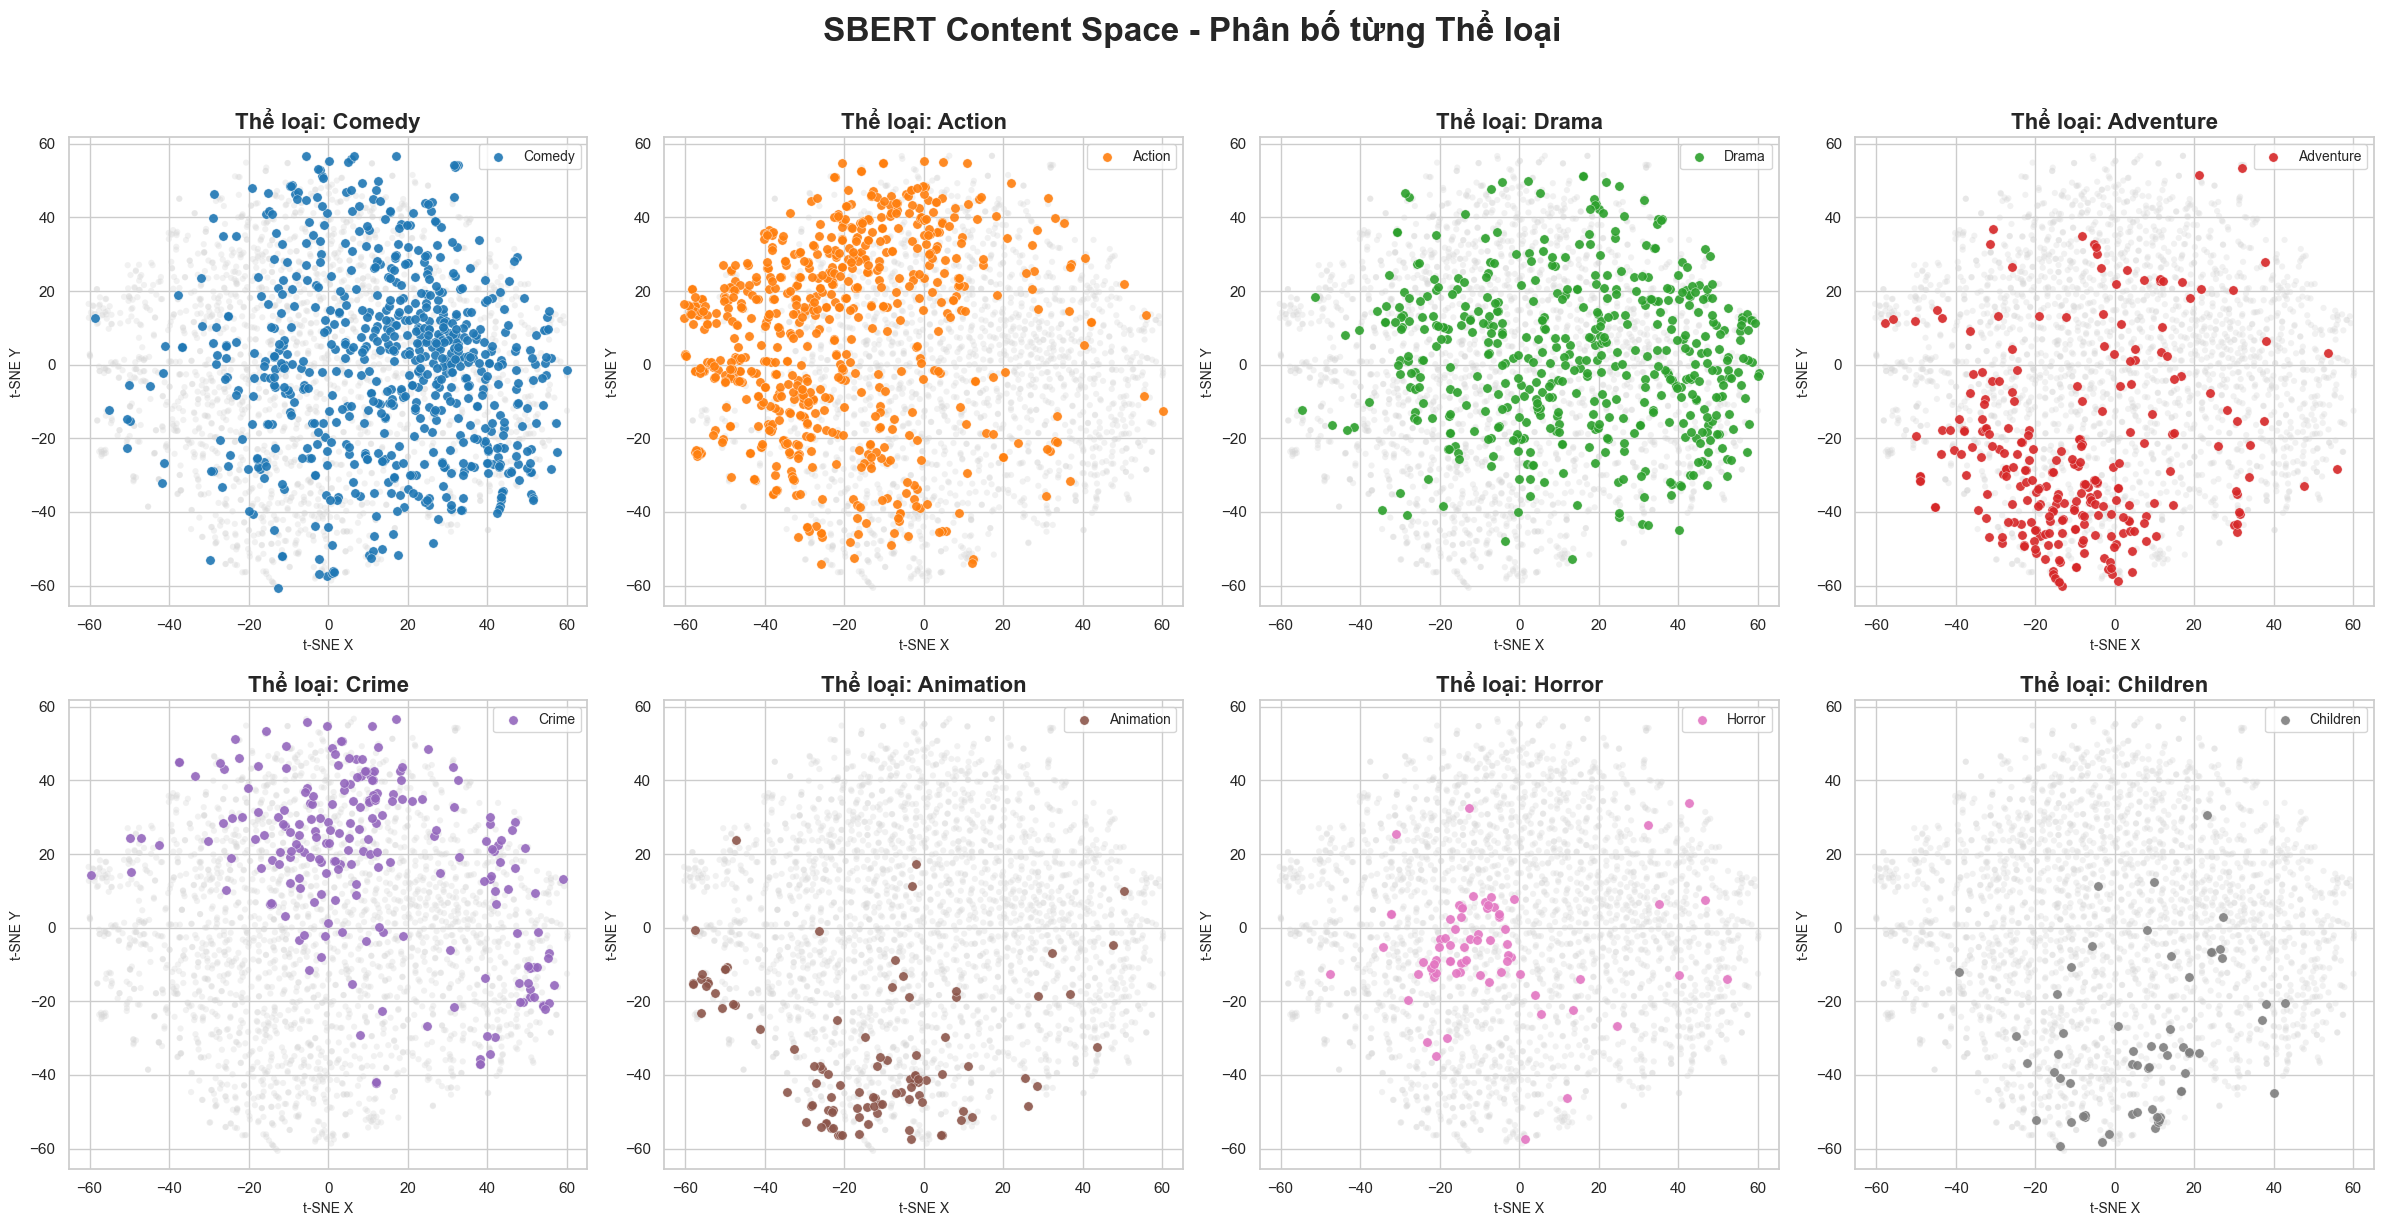

In [9]:
import math

print("4. Đang kết xuất biểu đồ cho TỪNG THỂ LOẠI...")

# Cấu hình lưới: 2 hàng, 4 cột
cols = 4
rows = math.ceil(len(top_genres) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(24, 6 * rows))
axes = axes.flatten()

for i, genre in enumerate(top_genres):
    ax = axes[i]
    
    # 1. Vẽ toàn bộ phim khác bằng màu xám nhạt (Làm nền)
    other_genres = df_plot[df_plot['Genre'] != genre]
    sns.scatterplot(x='X', y='Y', data=other_genres, color='lightgray', s=20, alpha=0.3, edgecolor="none", ax=ax)
    
    # 2. Vẽ đè phim của thể loại hiện tại lên trên cho nổi bật
    current_genre = df_plot[df_plot['Genre'] == genre]
    sns.scatterplot(x='X', y='Y', data=current_genre, color=color_map[genre], s=45, alpha=0.9, edgecolor="white", linewidth=0.3, label=genre, ax=ax)
    
    # Cố định trục tọa độ cho mọi ô để dễ so sánh
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(f'Thể loại: {genre}', fontsize=16, fontweight='bold')
    ax.set_xlabel('t-SNE X', fontsize=10)
    ax.set_ylabel('t-SNE Y', fontsize=10)
    ax.legend(loc='upper right', fontsize='10')

# Xóa các ô trống nếu số lượng thể loại không lấp đủ lưới
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('SBERT Content Space - Phân bố từng Thể loại', fontsize=24, fontweight='bold', y=1.02)
plt.tight_layout()

plt.show()

5. Đang kết xuất biểu đồ GỘP TỔNG...


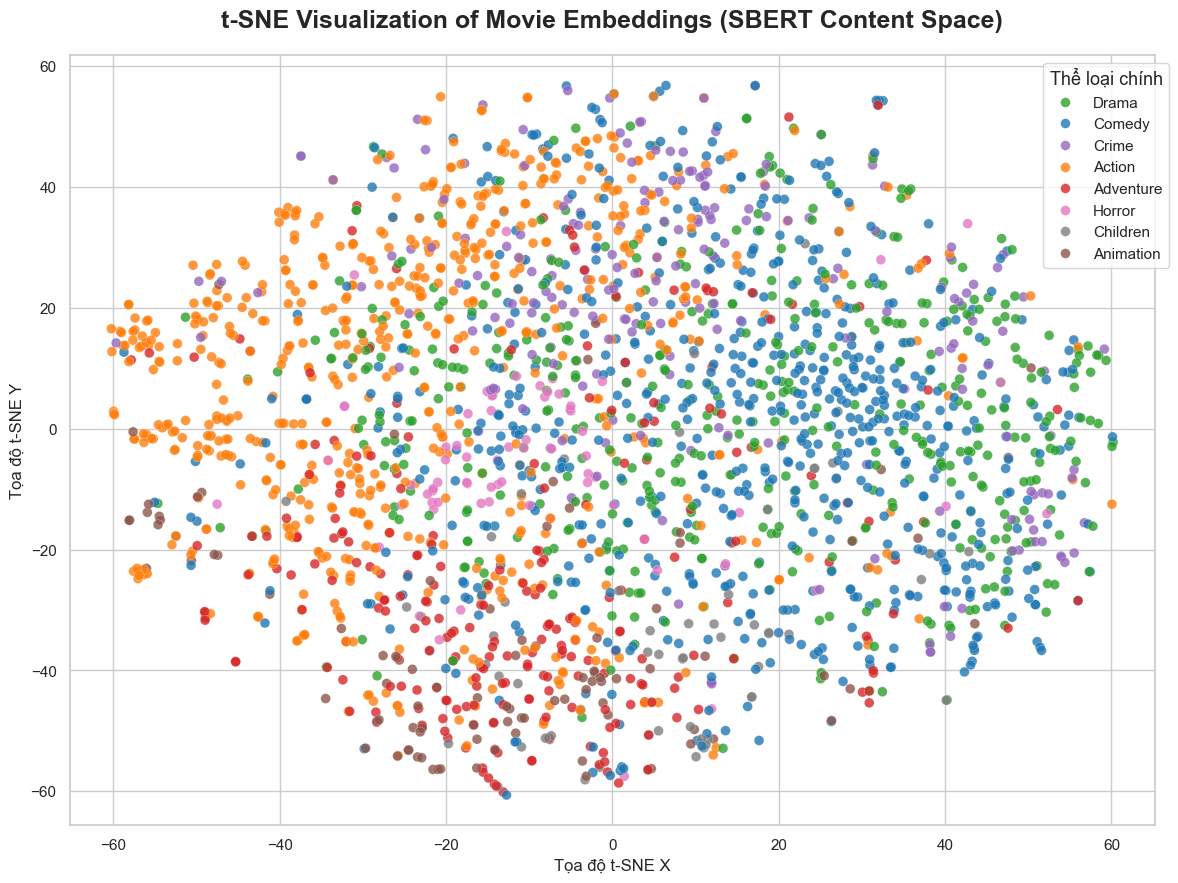

In [10]:
print("5. Đang kết xuất biểu đồ GỘP TỔNG...")
plt.figure()

sns.scatterplot(
    x='X', y='Y',
    hue='Genre',
    palette=color_map,
    data=df_plot,
    s=50,
    alpha=0.8,
    edgecolor="w",
    linewidth=0.2
)

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.title('t-SNE Visualization of Movie Embeddings (SBERT Content Space)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Tọa độ t-SNE X', fontsize=12)
plt.ylabel('Tọa độ t-SNE Y', fontsize=12)
plt.legend(title='Thể loại chính', title_fontsize='13', fontsize='11', loc='best', bbox_to_anchor=(1.02, 1))

output_img = "artifacts/embedding_visualization_SBERT_ALL.png"
plt.savefig(output_img, dpi=300, bbox_inches='tight')
plt.show()

### Biểu đồ này chứng minh điều gì?

Nhìn vào biểu đồ trên, ta thấy các bộ phim (các chấm) đã được tự động gom thành từng cụm tương đối rõ ràng. Đây chính là bằng chứng cho thấy mô hình SBERT đã thực sự "hiểu" được mối quan hệ về nội dung giữa các bộ phim:

1. **Phân tích dựa trên nội dung cốt truyện:** Trong quá trình xử lý, AI hoàn toàn không được cung cấp nhãn thể loại. Nó chỉ phân tích phần tóm tắt nội dung (text) rồi tự động mã hóa thành các chuỗi số vector.
   
2. **Khám phá sự giao thoa ngữ nghĩa:** Các phim có nội dung giống nhau sẽ tự động hội tụ lại gần nhau. Đặc biệt, sự đan xen màu sắc ở các vùng ranh giới phản ánh rất đúng thực tế: một bộ phim Hành động có yếu tố gây cười sẽ nằm ở giữa cụm Action và Comedy. AI gom cụm theo ngữ nghĩa thực tế chứ không bị gò bó bởi nhãn dán cứng nhắc.